# Random Testing Yahoo stuff

In [1]:
##Ignore this stuff
'''
import pandas as pd
import numpy as np
import yfinance as yf  # to fetch historical price data
import plotly.express as px
import matplotlib.pyplot as plt

# Step 1: Data Collection
import yfinance as yf
dat = yf.Ticker("MSFT")
#(dat.info)
#print(dat.calendar)
#print(dat.analyst_price_targets)
#print(dat.quarterly_income_stmt)
#test = pd.DataFrame(dat.history(period='max'))
#df = pd.DataFrame(dat.option_chain(dat.options[0]).puts)
'''
'''
prices = data['Adj Close']

# Step 2: Calculate Returns
returns = prices.pct_change().dropna()

# Step 3: Calculate Basic Risk Metrics
volatility = returns.std()  # standard deviation of returns
variance = returns.var()
mean_return = returns.mean()

# Example: Calculate Beta relative to S&P 500
benchmark = '^GSPC'
benchmark_data = yf.download(benchmark, start='2020-01-01', end='2023-01-01')
benchmark_returns = benchmark_data['Adj Close'].pct_change().dropna()

cov_matrix = np.cov(returns, benchmark_returns)
cov = cov_matrix[0, 1]
benchmark_var = benchmark_returns.var()
beta = cov / benchmark_var

# Step 4: Calculate Sharpe Ratio (assuming risk-free rate is 0 for simplicity)
sharpe_ratio = mean_return / volatility

print(f"Volatility (Std Dev): {volatility}")
print(f"Variance: {variance}")
print(f"Beta: {beta}")
print(f"Sharpe Ratio: {sharpe_ratio}")
'''
#df.sort_values('lastTradeDate', ascending = False).head(30)
#dat.live()
#test

'\nprices = data[\'Adj Close\']\n\n# Step 2: Calculate Returns\nreturns = prices.pct_change().dropna()\n\n# Step 3: Calculate Basic Risk Metrics\nvolatility = returns.std()  # standard deviation of returns\nvariance = returns.var()\nmean_return = returns.mean()\n\n# Example: Calculate Beta relative to S&P 500\nbenchmark = \'^GSPC\'\nbenchmark_data = yf.download(benchmark, start=\'2020-01-01\', end=\'2023-01-01\')\nbenchmark_returns = benchmark_data[\'Adj Close\'].pct_change().dropna()\n\ncov_matrix = np.cov(returns, benchmark_returns)\ncov = cov_matrix[0, 1]\nbenchmark_var = benchmark_returns.var()\nbeta = cov / benchmark_var\n\n# Step 4: Calculate Sharpe Ratio (assuming risk-free rate is 0 for simplicity)\nsharpe_ratio = mean_return / volatility\n\nprint(f"Volatility (Std Dev): {volatility}")\nprint(f"Variance: {variance}")\nprint(f"Beta: {beta}")\nprint(f"Sharpe Ratio: {sharpe_ratio}")\n'

# Actual Stuff

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf  # to fetch historical price data
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from sklearn.decomposition import PCA
# Step 1: Data Collection
import yfinance as yf

In [57]:
class StockPortfolio:
    '''
    This class is to help us manage data regarding a given list of stock tickers
    tickList: list or string of our stock tickers
    tickerList: Dictionary of our ticker names with the yf ticker object
    timePeriod: how far we want to look back on historical data,  must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max ,,, defaulting to 1 year
    data: A dataframe provided by yahoo finance api that gives us the daily open, close, adjusted close prices, highs and lows, and trading volume
            information for our tickers during a specified time period
    '''
    def __init__(self, tickList):
        self.tickerList = yf.Tickers(tickList).tickers
        self.timePeriod = '1y'
        self.data = yf.download(list(self.tickerList.keys()), period = self.timePeriod, auto_adjust = False) #tickers.tickers is a dictionary of yf ticker objects with keys being the ticker names
    def getSimpleChangeHistory(self, feature: str) -> pd.DataFrame:
        '''
        feature is what feature we want to see the % change in for that day, eg Close Price, Volume, Open Price
        This method calculates the daily closing price pct changes,
        calculated by taking the difference between the kth and (k-1)th day's non-adjusted closing price
        then dividing this difference by the (k-1)th close price to find the pct change after the kth day's market close
        '''
        #data = yf.download(list(self.YfTickers.keys()), period = timePeriod, auto_adjust = False) #tickers.tickers is a dictionary of yf ticker objects with keys being the ticker names
        self.simpleReturn = self.data[(feature,)].pct_change().dropna()
        return self.simpleReturn
    def getLogChangeHistory(self, feature: str) -> pd.DataFrame:
        '''
        This Method calculates the log return for each day, ln(Close Price of Today/close price of yesterday)
        '''
        self.logReturn = np.log(self.data[(feature,)]) - np.log(self.data[(feature,)].shift(1)).dropna()
        return self.logReturn
    def change_timePeriod(self, newTimePeriod: str) -> None:
        '''
        This method changes the time period for the historical data we want to look at
        '''
        self.timePeriod = newTimePeriod
        self.data = yf.download(list(self.tickerList.keys()), period = self.timePeriod, auto_adjust = False) #tickers.tickers is a dictionary of yf ticker objects with keys being the ticker names
        '''
    def simpleReturnVolatility(self) -> float:
        We Actually don't need this
        mean = self.getSimpleReturnHistory().mean()
        std = self.getSimpleReturnHistory().std()
        return std 
    def logReturnVolatility(self) -> float:
        I don't think we need this either
        mean = self.getLogReturnHistory().mean()
        std = self.getLogReturnHistory().std()
        return std
        '''
    def simpleMovingAverage(self,  feature: str, dayWindow: int) -> pd.DataFrame:
        '''
        This method calculates the Simple Moving Average for a specific time window of our non-adjusted Close Prices
        '''
        return self.data[(feature, )].rolling(window = dayWindow).mean()
    def exponentialMovingAverage(self, feature: str, dayWindow: int) -> pd.DataFrame:
        '''
        feature: Any of the features of our stock data, examples: Volume Close Price
        
        This method calculates the exponential moving average for a specific time window of our non-adjusted Close Prices
        This one is more weighted by recent prices, so looking at the difference between the Simple Moving and Exponential moving
        can give some insight into the momentum of the price changes
        '''
        return self.data[(feature, )].ewm(span=dayWindow, adjust=False).mean()
    def extractColumns(self, cols:list,tick:list)->pd.DataFrame:
        newData = test.data.loc[:, (cols, tick)]
        return newData
    def plotMovingAveragesDiff(self,feature: str, timeWindow: int, ticker: str) -> go.Figure:
        '''
        This method creates a figure displaying the moving averages and their difference for a desired time window and ticker
        '''
        df1 = test.simpleMovingAverage(feature,timeWindow)
        df2 = test.exponentialMovingAverage(feature,timeWindow)
        df3 = test.exponentialMovingAverage(feature,timeWindow) - test.simpleMovingAverage(feature,timeWindow)
        newDf = pd.DataFrame()
        newDf['SMA'] = df1[ticker]
        newDf['EMA'] = df2[ticker]
        newDf['Diff'] = df3[ticker]
        fig = go.Figure()

        # Add SMA trace (primary y-axis)
        fig.add_trace(go.Scatter(x=newDf.index, y=newDf['SMA'], mode='lines', name='SMA'))

        # Add EMA trace (primary y-axis)
        fig.add_trace(go.Scatter(x=newDf.index, y=newDf['EMA'], mode='lines', name='EMA'))

        # Add Difference trace (secondary y-axis)
        fig.add_trace(go.Scatter(x=newDf.index, y=newDf['Diff'], mode='lines', name='Difference', yaxis='y2'))

        # Update layout for two y-axes
        diff_min = newDf['Diff'].min()
        diff_max = newDf['Diff'].max()
        padding = (diff_max - diff_min) * 0.1  # 10% padding
        fig.update_layout(
            title=f'Simple Moving Average and Exponential Moving Average of {feature} over {timeWindow} day window, and Their Difference with Dual Y-Axis for {ticker}',
            xaxis=dict(title='Date'),
            yaxis=dict(title='SMA and EMA'),
            yaxis2=dict(
                title='Difference',
                overlaying='y',
                side='right',
                showgrid=False,
                zeroline=True,
                zerolinecolor='gray',
                range=[diff_min - padding, diff_max + padding]
            ),
            legend=dict(x=0, y=-1)
        )
        return fig
    def MovingAverages(self, feature: str, timeWindow: str) -> pd.DataFrame:
        df1 = test.simpleMovingAverage(feature,timeWindow)
        df2 = test.exponentialMovingAverage(feature,timeWindow)
        df3 = test.exponentialMovingAverage(feature,timeWindow) - test.simpleMovingAverage(feature,timeWindow)
        newDf = pd.DataFrame()
        combined = pd.concat([df1, df2, df3], axis=1, keys=['SMA', 'EMA', 'Diff'])
        #newDf[('SMA',)] = df1
        #newDf[('EMA',)] = df2
        #newDf[('Diff',)] = df3
        combined = pd.concat([df1, df2, df3], axis=1, keys=['SMA', 'EMA', 'Diff'])
        return combined

In [58]:
test = StockPortfolio(['MSFT', 'AAPL','GOOG','UNH','NVDA','KO','BA','MDT','MCD','SO','NKE'])
test.change_timePeriod('1y')


[*********************100%***********************]  11 of 11 completed
[*********************100%***********************]  11 of 11 completed


In [59]:
test.data

Price        Adj Close                                                 \
Ticker            AAPL          BA        GOOG         KO         MCD   
Date                                                                    
2024-11-18  226.993362  143.869995  176.029572  60.053783  284.460815   
2024-11-19  227.252197  145.600006  178.797440  60.762466  284.099243   
2024-11-20  227.968948  146.080002  176.557266  61.150787  284.275177   
2024-11-21  227.491119  143.410004  168.502518  61.898304  281.890778   
2024-11-22  228.835037  149.289993  165.844162  62.053635  283.659485   
...                ...         ...         ...        ...         ...   
2025-11-11  275.250000  195.210007  291.739990  71.610001  306.829987   
2025-11-12  273.470001  195.500000  287.429993  71.510002  306.940002   
2025-11-13  272.950012  194.580002  279.119995  71.070000  307.579987   
2025-11-14  272.410004  194.520004  276.980011  71.160004  307.029999   
2025-11-17  267.459991  191.809998  285.600006  70.680000  304.899994   

Price                                                                ...  \
Ticker            MDT        MSFT        NKE        NVDA         SO  ...   
Date                                                                 ...   
2024-11-18  84.802330  412.661957  73.264320  140.109802  85.890053  ...   
2024-11-19  82.294762  414.676788  72.305595  146.967850  86.133957  ...   
2024-11-20  81.433090  412.393921  71.767540  145.848175  85.821762  ...   
2024-11-21  82.043037  410.613708  73.469765  146.627960  85.987617  ...   
2024-11-22  83.466255  414.721161  75.719833  141.909302  85.460800  ...   
...               ...         ...        ...         ...        ...  ...   
2025-11-11  95.400002  508.679993  63.150002  193.160004  91.139999  ...   
2025-11-12  95.809998  511.140015  64.199997  193.800003  91.889999  ...   
2025-11-13  96.139999  503.290009  66.029999  186.860001  91.169998  ...   
2025-11-14  95.870003  510.179993  64.169998  190.169998  90.690002  ...   
2025-11-17  96.279999  507.489990  62.900002  186.600006  90.580002  ...   

Price         Volume                                                   \
Ticker            BA      GOOG        KO      MCD       MDT      MSFT   
Date                                                                    
2024-11-18  12251600  18662800  16062100  2865000  10339800  24727000   
2024-11-19   8247300  15392900  16254800  2353300  12000800  18133500   
2024-11-20   9232100  15729800  18904900  2524600   7389100  19191700   
2024-11-21   7845100  38839400  17292300  4475700   5699700  20780200   
2024-11-22  13353100  24497000  19562200  2879100   6532100  24814600   
...              ...       ...       ...      ...       ...       ...   
2025-11-11   5783400  14156700  16160200  2755800   8555500  17980000   
2025-11-12   8288300  16998800  13612600  2818600   6322000  26574900   
2025-11-13   6739300  18060200  14002800  2294300   5284400  25273100   
2025-11-14   6189800  18330500  13172000  3112500   6324500  28505700   
2025-11-17   5865800  34197900  14763900  2435100  11082900  19070200   

Price                                               
Ticker           NKE       NVDA       SO       UNH  
Date                                                
2024-11-18  12595100  221205300  4991500   2577100  
2024-11-19  12028400  227834900  3546400   3198300  
2024-11-20  12290300  309871700  4239900   3928600  
2024-11-21  12818600  400946600  5635600   2722900  
2024-11-22  12248600  236406200  3440000   3197900  
...              ...        ...      ...       ...  
2025-11-11  17646400  176483300  3885400   7157800  
2025-11-12  14812200  154935300  5588400  10403300  
2025-11-13  21923600  207423100  5696400   7788700  
2025-11-14  17760100  186591900  4613600   8676500  
2025-11-17  17059000  172821100  5709100   6469000  

[250 rows x 66 columns]

In [60]:
cols = ['Close', 'Open', 'Volume']
tic = ['MSFT']
test2 = test.extractColumns(cols,tic)
test2

Price,Close,Open,Volume
Ticker,MSFT,MSFT,MSFT
Date,,,
2024-11-18,415.760010,414.869995,24727000
2024-11-19,417.790009,413.109985,18133500
2024-11-20,415.489990,416.869995,19191700
2024-11-21,412.869995,419.500000,20780200
2024-11-22,417.000000,411.369995,24814600
...,...,...,...
2025-11-11,508.679993,504.799988,17980000
2025-11-12,511.140015,509.359985,26574900


In [128]:
test.change_timePeriod('1y')

[*********************100%***********************]  11 of 11 completed


In [132]:
timeWindow = 60

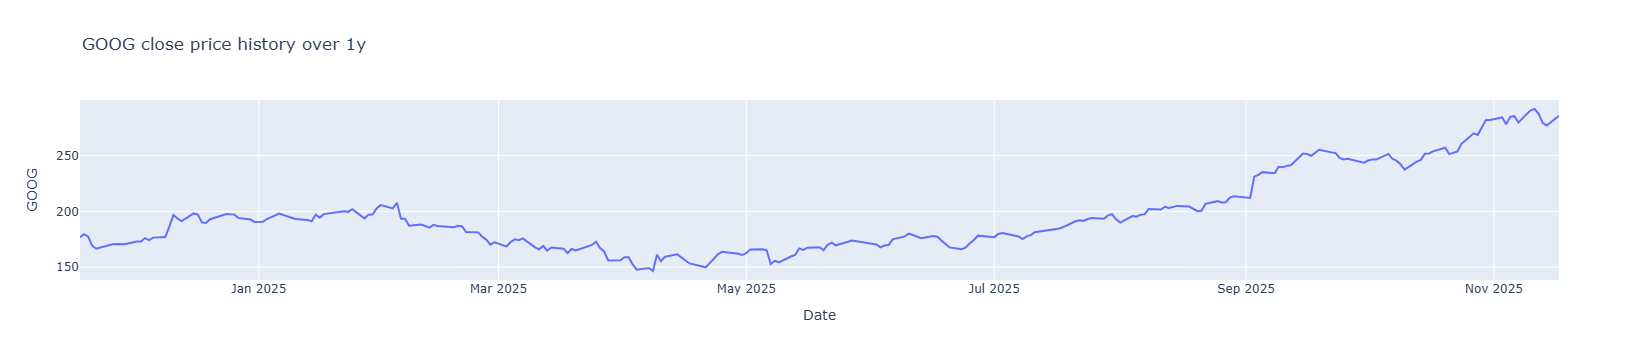

In [133]:
df = test.data[('Close',)]
fig = px.line(df, x = df.index, y = df['GOOG'], title = f'{df.columns[2]} close price history over {test.timePeriod}')
fig.show()

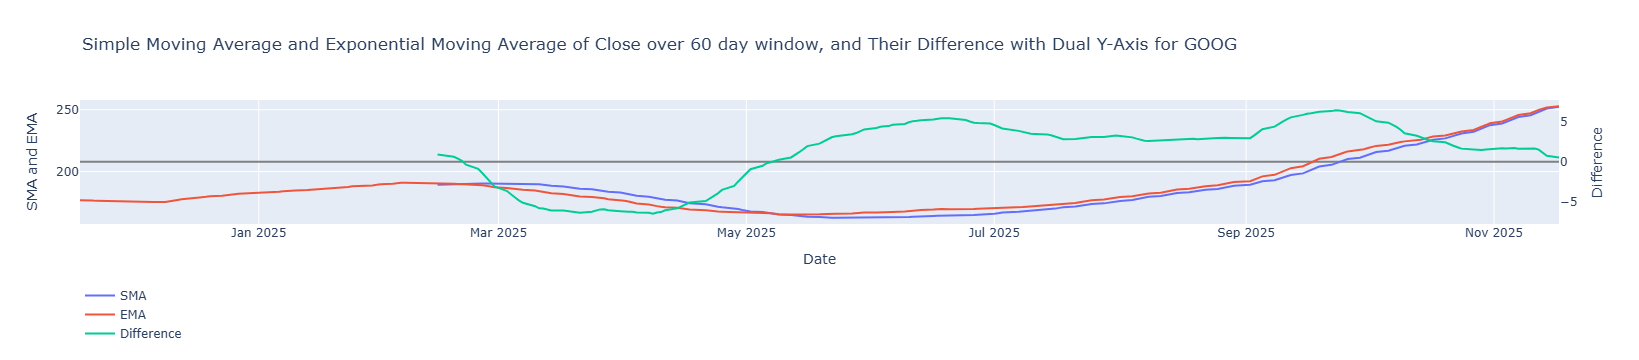

In [134]:
test.plotMovingAveragesDiff('Close',timeWindow,'GOOG').show()

In [135]:
feature = 'Close'
df = test.data[(feature,)]
tick = 'KO'

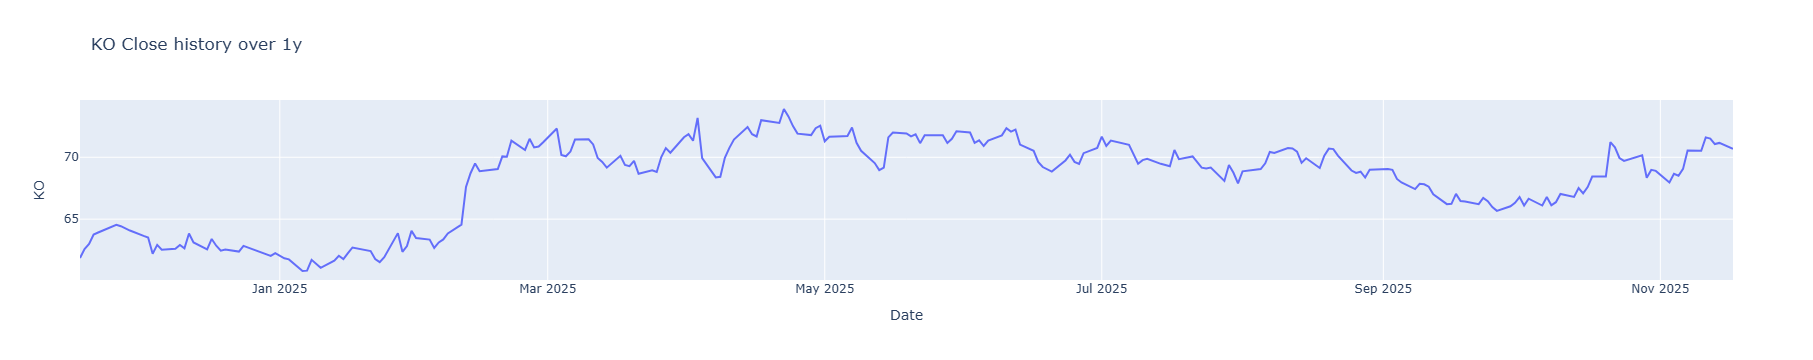

In [136]:
fig = px.line(df, x = df.index, y = df[df.columns[df.columns.get_loc(tick)]], title = f'{df.columns[df.columns.get_loc(tick)]} {feature} history over {test.timePeriod}')
fig.show()

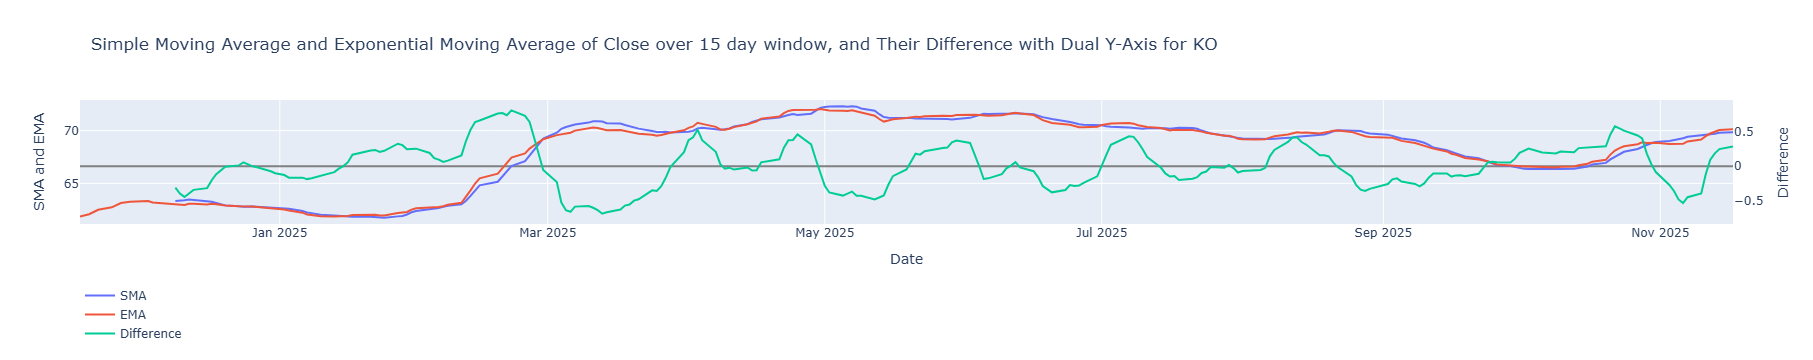

In [137]:
test.plotMovingAveragesDiff('Close',15,'KO').show()

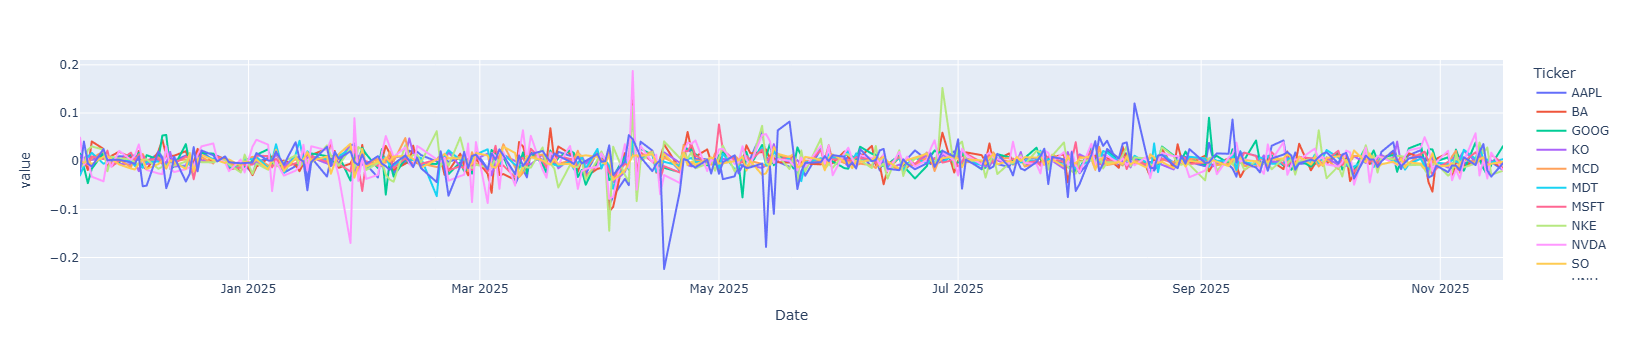

In [36]:
df = test.getSimpleChangeHistory('Close')
fig = px.line(df, x = df.index, y = df.columns)
fig.show()

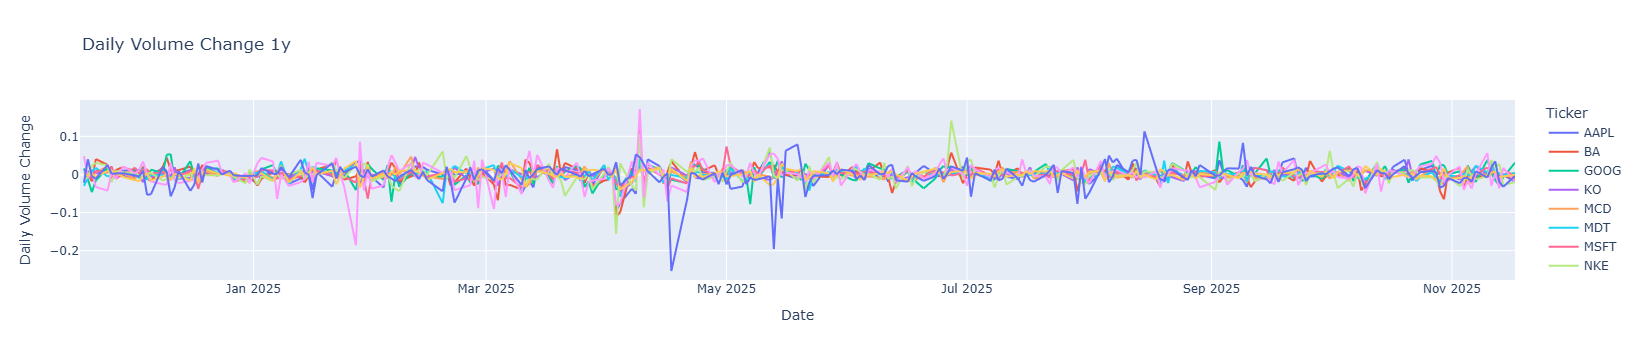

In [35]:
df = test.getLogChangeHistory('Close')
fig = px.line(df, x = df.index, y = df.columns, title = f'Daily Volume Change {test.timePeriod}')
fig.update_layout(yaxis_title="Daily Volume Change")
fig.show()

In [141]:
returns = test.getLogChangeHistory('Close').dropna()
summary_stats = returns.describe().T
summary_stats['skew'] = returns.skew()
summary_stats['kurtosis'] = returns.kurtosis()
corr_matrix = returns.corr()
cov_matrix = returns.cov()
corr_matrix

Ticker,AAPL,BA,GOOG,KO,MCD,MDT,MSFT,NKE,NVDA,SO,UNH
Ticker,,,,,,,,,,,
AAPL,1.000000,0.465041,0.484821,0.112353,0.248017,0.337946,0.504967,0.456731,0.403635,0.040667,0.034394
BA,0.465041,1.000000,0.335030,0.026665,0.087804,0.251092,0.405086,0.404266,0.390741,-0.058727,0.037327
GOOG,0.484821,0.335030,1.000000,-0.157606,0.059064,0.076397,0.473212,0.277293,0.463385,-0.173279,0.062646
KO,0.112353,0.026665,-0.157606,1.000000,0.476286,0.340999,-0.107981,0.069122,-0.232429,0.607956,0.005082
MCD,0.248017,0.087804,0.059064,0.476286,1.000000,0.330963,0.041338,0.115438,-0.102408,0.481160,0.143740
MDT,0.337946,0.251092,0.076397,0.340999,0.330963,1.000000,0.157552,0.187444,0.074355,0.346881,0.176332
MSFT,0.504967,0.405086,0.473212,-0.107981,0.041338,0.157552,1.000000,0.237275,0.620144,-0.122149,0.037816
NKE,0.456731,0.404266,0.277293,0.069122,0.115438,0.187444,0.237275,1.000000,0.204187,0.019546,-0.032102
NVDA,0.403635,0.390741,0.463385,-0.232429,-0.102408,0.074355,0.620144,0.204187,1.000000,-0.234632,0.010502


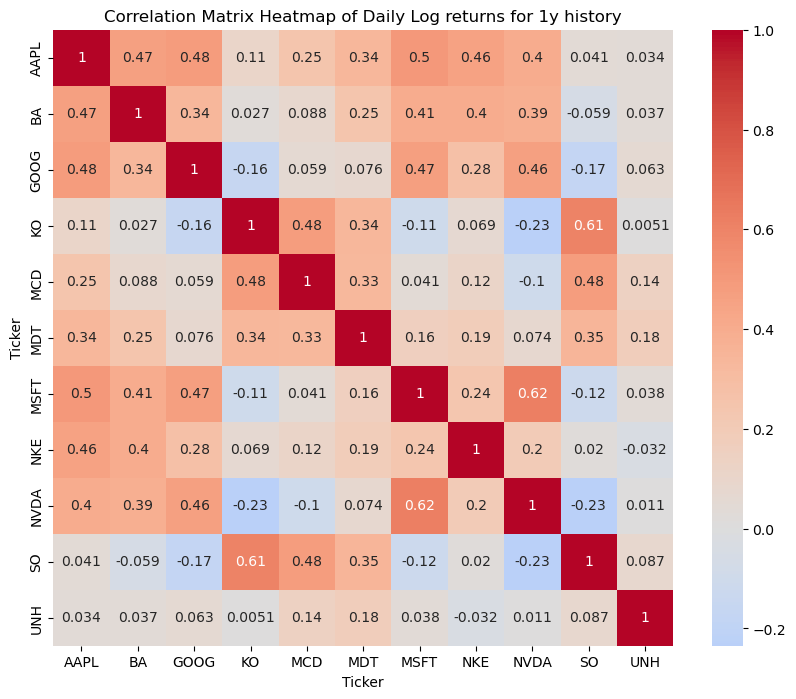

In [142]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title(f'Correlation Matrix Heatmap of Daily Log returns for {test.timePeriod} history' )
plt.show()

In [139]:
returns = test.getLogChangeHistory('Volume').dropna()
summary_stats = returns.describe().T
summary_stats['skew'] = returns.skew()
summary_stats['kurtosis'] = returns.kurtosis()
corr_matrix = returns.corr()
cov_matrix = returns.cov()
corr_matrix

Ticker,AAPL,BA,GOOG,KO,MCD,MDT,MSFT,NKE,NVDA,SO,UNH
Ticker,,,,,,,,,,,
AAPL,1.000000,0.267566,0.480121,0.552671,0.491442,0.366940,0.589462,0.417510,0.400026,0.346732,0.332931
BA,0.267566,1.000000,0.249768,0.340270,0.136780,0.143541,0.287281,0.256145,0.138394,0.148662,0.286060
GOOG,0.480121,0.249768,1.000000,0.454345,0.351820,0.271251,0.510419,0.314650,0.347165,0.345009,0.254356
KO,0.552671,0.340270,0.454345,1.000000,0.439197,0.401367,0.560908,0.379416,0.343782,0.422333,0.304682
MCD,0.491442,0.136780,0.351820,0.439197,1.000000,0.280539,0.461857,0.410863,0.373105,0.444029,0.256178
MDT,0.366940,0.143541,0.271251,0.401367,0.280539,1.000000,0.296143,0.314332,0.229827,0.309908,0.274865
MSFT,0.589462,0.287281,0.510419,0.560908,0.461857,0.296143,1.000000,0.382653,0.476876,0.430000,0.301200
NKE,0.417510,0.256145,0.314650,0.379416,0.410863,0.314332,0.382653,1.000000,0.285366,0.363842,0.260012
NVDA,0.400026,0.138394,0.347165,0.343782,0.373105,0.229827,0.476876,0.285366,1.000000,0.301860,0.271735


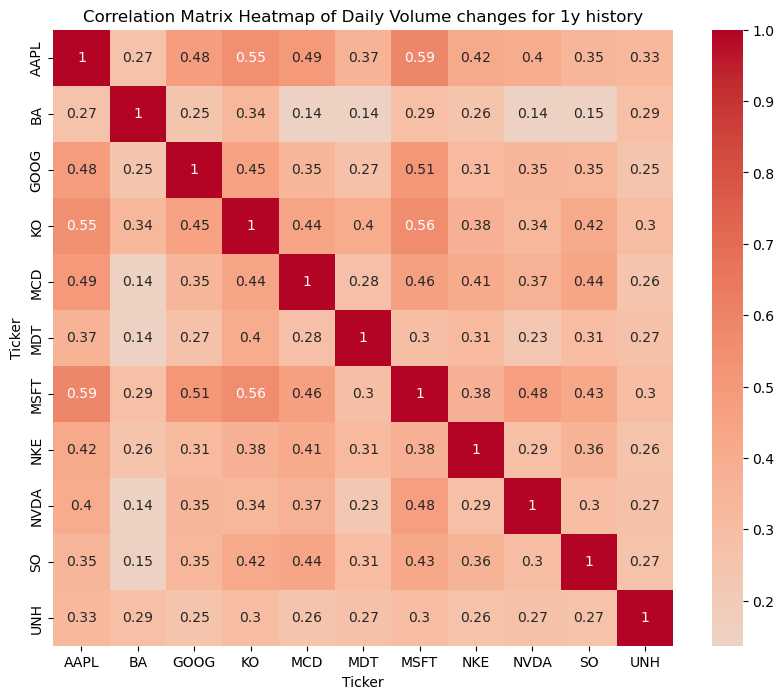

In [140]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title(f'Correlation Matrix Heatmap of Daily Volume changes for {test.timePeriod} history' )
plt.show()

In [18]:
'''
fig = px.scatter_matrix(returns)
fig.update_traces(showupperhalf=False,diagonal_visible=False)
fig.update_layout(
    title=dict(text='Pair Plot of Returns'),
    width=1000,
    height=1000,
)
fig.show()
'''

"\nfig = px.scatter_matrix(returns)\nfig.update_traces(showupperhalf=False,diagonal_visible=False)\nfig.update_layout(\n    title=dict(text='Pair Plot of Returns'),\n    width=1000,\n    height=1000,\n)\nfig.show()\n"

# Random Stuff I'm testing

In [143]:
test.change_timePeriod('1y')
returns = test.MovingAverages('Close',70)[('Diff',)]
summary_stats = returns.describe().T
summary_stats['skew'] = returns.skew()
summary_stats['kurtosis'] = returns.kurtosis()
corr_matrix = returns.corr()
cov_matrix = returns.cov()
corr_matrix

[*********************100%***********************]  11 of 11 completed


Ticker,AAPL,BA,GOOG,KO,MCD,MDT,MSFT,NKE,NVDA,SO,UNH
Ticker,,,,,,,,,,,
AAPL,1.000000,0.131344,0.924645,-0.637902,-0.308974,0.352991,0.090698,0.460277,0.295850,-0.536238,0.355005
BA,0.131344,1.000000,0.350818,-0.642417,-0.604791,-0.022956,0.945632,0.586435,0.913284,-0.448097,-0.811397
GOOG,0.924645,0.350818,1.000000,-0.802148,-0.435806,0.165584,0.323162,0.397369,0.431888,-0.766345,0.085849
KO,-0.637902,-0.642417,-0.802148,1.000000,0.605013,0.151476,-0.671466,-0.408875,-0.668423,0.785846,0.236534
MCD,-0.308974,-0.604791,-0.435806,0.605013,1.000000,-0.045918,-0.764603,-0.468644,-0.782362,0.424626,0.471444
MDT,0.352991,-0.022956,0.165584,0.151476,-0.045918,1.000000,-0.168139,0.697477,0.175931,0.425469,0.270127
MSFT,0.090698,0.945632,0.323162,-0.671466,-0.764603,-0.168139,1.000000,0.474656,0.910706,-0.508085,-0.835030
NKE,0.460277,0.586435,0.397369,-0.408875,-0.468644,0.697477,0.474656,1.000000,0.776161,0.055629,-0.180646
NVDA,0.295850,0.913284,0.431888,-0.668423,-0.782362,0.175931,0.910706,0.776161,1.000000,-0.345209,-0.645035


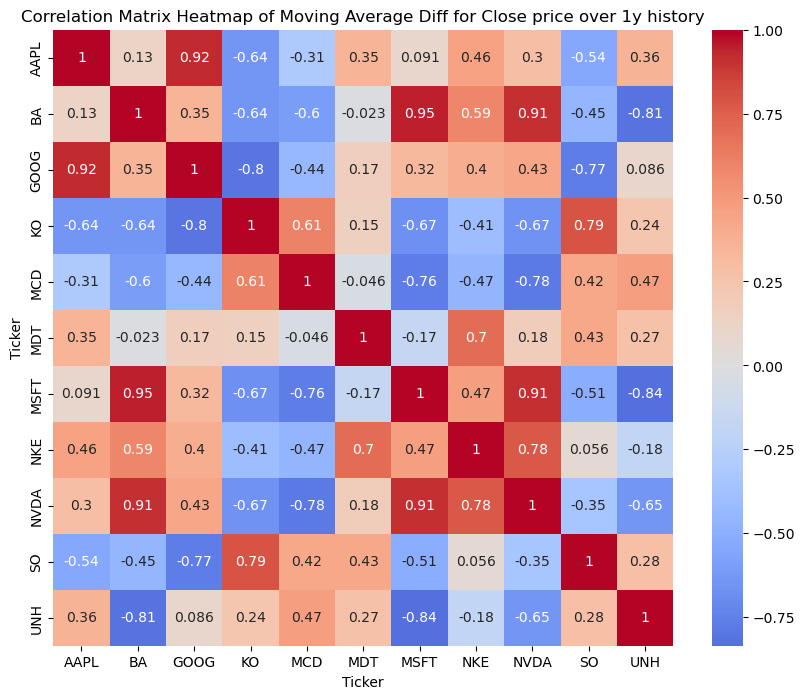

In [144]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title(f'Correlation Matrix Heatmap of Moving Average Diff for Close price over {test.timePeriod} history' )
plt.show()

In [117]:
test.MovingAverages('Close',70)[('Diff',)]

Ticker,AAPL,BA,GOOG,KO,MCD,MDT,MSFT,NKE,NVDA,SO,UNH
Date,,,,,,,,,,,
2024-11-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-11,2.153466,-5.807095,3.425123,0.267094,-1.773658,-0.640985,-4.288993,-2.447354,-1.174357,-0.202506,9.107453
2025-11-12,1.851906,-5.897270,3.335218,0.312882,-1.799839,-0.648410,-4.013478,-2.429610,-1.056492,-0.222206,7.876245
2025-11-13,1.670802,-5.983290,3.118266,0.356853,-1.692685,-0.657944,-3.888166,-2.367148,-1.027979,-0.246199,6.478914


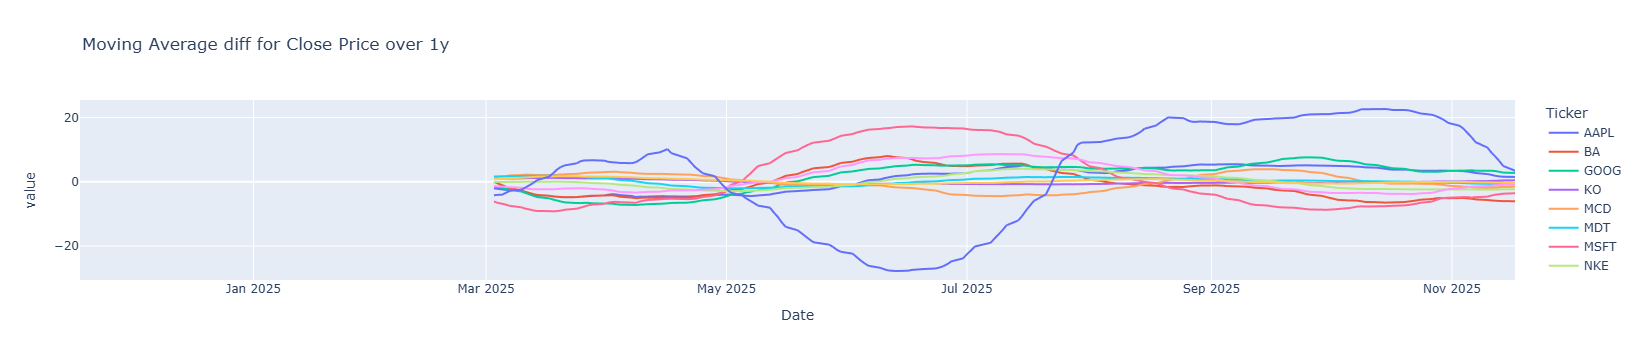

In [147]:
test.change_timePeriod('1y')
returns = test.MovingAverages('Volume',70)[('Diff',)]
summary_stats = returns.describe().T
summary_stats['skew'] = returns.skew()
summary_stats['kurtosis'] = returns.kurtosis()
corr_matrix = returns.corr()
cov_matrix = returns.cov()
corr_matrix

[*********************100%***********************]  11 of 11 completed


Ticker,AAPL,BA,GOOG,KO,MCD,MDT,MSFT,NKE,NVDA,SO,UNH
Ticker,,,,,,,,,,,
AAPL,1.000000,0.515504,0.121794,0.327974,0.400838,-0.110949,0.766384,0.479003,0.498151,-0.421380,-0.074575
BA,0.515504,1.000000,0.627272,0.267725,0.248902,0.024010,0.283845,0.765181,0.241453,-0.078113,0.020496
GOOG,0.121794,0.627272,1.000000,0.073442,0.141608,0.400792,0.042889,0.511912,-0.009470,0.184550,0.394761
KO,0.327974,0.267725,0.073442,1.000000,0.733175,0.295936,0.547427,0.619697,0.699134,0.152568,-0.719675
MCD,0.400838,0.248902,0.141608,0.733175,1.000000,0.355409,0.482576,0.598399,0.371064,0.258257,-0.645076
MDT,-0.110949,0.024010,0.400792,0.295936,0.355409,1.000000,0.113010,0.273069,0.213106,0.483240,-0.062962
MSFT,0.766384,0.283845,0.042889,0.547427,0.482576,0.113010,1.000000,0.419472,0.789081,-0.125921,-0.199029
NKE,0.479003,0.765181,0.511912,0.619697,0.598399,0.273069,0.419472,1.000000,0.495515,0.091843,-0.386824
NVDA,0.498151,0.241453,-0.009470,0.699134,0.371064,0.213106,0.789081,0.495515,1.000000,0.133006,-0.421251


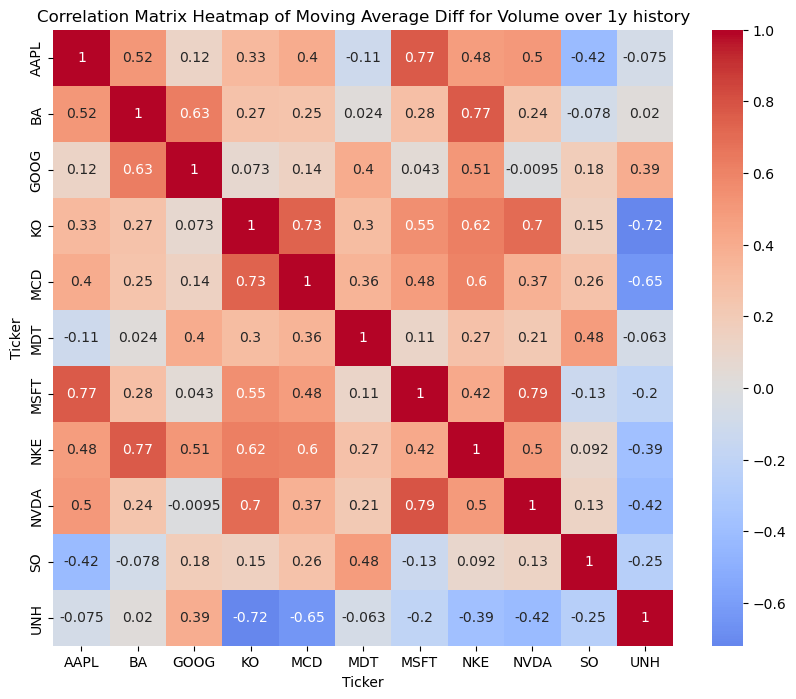

In [148]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title(f'Correlation Matrix Heatmap of Moving Average Diff for Volume over {test.timePeriod} history' )
plt.show()

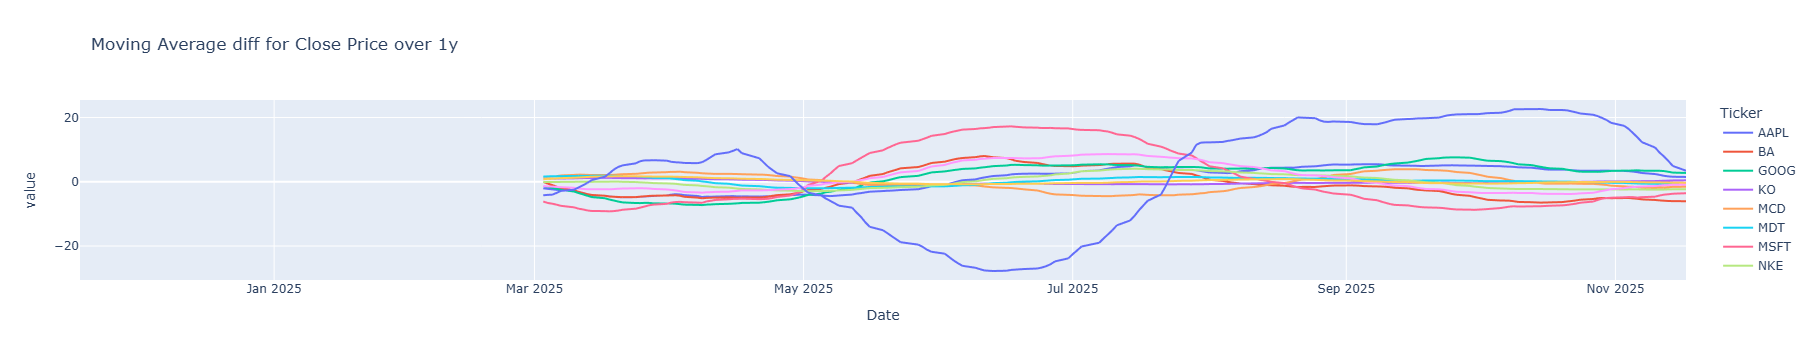

In [145]:
df = test.MovingAverages('Close',70)[('Diff',)]
fig = px.line(df, x = df.index, y = df.columns, title = f'Moving Average diff for Close Price over {test.timePeriod}')
fig.show()

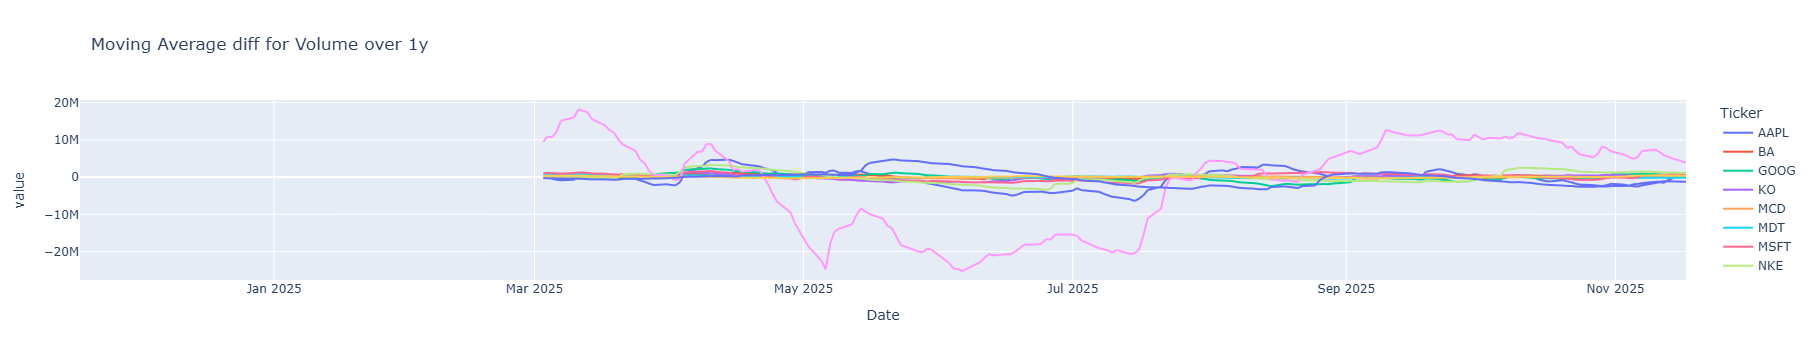

In [146]:
df = test.MovingAverages('Volume',70)[('Diff',)]
fig = px.line(df, x = df.index, y = df.columns, title = f'Moving Average diff for Volume over {test.timePeriod}')
fig.show()

In [159]:
returns = test.MovingAverages('Volume',70)[('Diff',)].dropna()
regression_results = {}
for stock in returns.columns:
    y = returns[stock]
    X = returns.drop(columns=stock)
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    regression_results[stock] = model.summary()
    print(regression_results[stock])

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     97.28
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           5.93e-65
Time:                        20:49:39   Log-Likelihood:                -2738.3
No. Observations:                 181   AIC:                             5499.
Df Residuals:                     170   BIC:                             5534.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -3.18e+05   1.22e+05     -2.608      0.0

In [160]:
pca = PCA(n_components=11)
pca.fit(returns)
pca_components = pca.components_
explained_variance = pca.explained_variance_ratio_
explained_variance

array([9.36091057e-01, 2.92992046e-02, 1.98905013e-02, 1.16545790e-02,
       1.34229365e-03, 7.39520987e-04, 3.93472647e-04, 3.31503908e-04,
       1.74895730e-04, 6.92123816e-05, 1.37585273e-05])

In [161]:
prices = returns
cointegration_results = {}
pairs = [(returns.columns[i], returns.columns[j]) for i in range(11) for j in range(i+1, 11)]
for stock1, stock2 in pairs:
    score, pvalue, _ = coint(prices[stock1], prices[stock2])
    cointegration_results[(stock1, stock2)] = {'score': score, 'pvalue': pvalue}
#cointegration_results

In [162]:
# Print cointegration test results (only pairs with p-value < 0.05)
print('\nCointegration test results (p-value < 0.05):')
for pair, result in cointegration_results.items():
    if result['pvalue'] < 0.05:
        print(f'{pair}: p-value={result["pvalue"]:.4f}, score={result["score"]:.4f}')


Cointegration test results (p-value < 0.05):
('AAPL', 'MSFT'): p-value=0.0345, score=-3.4773
('BA', 'NKE'): p-value=0.0457, score=-3.3711


In [163]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [164]:
#Run Johansen cointegration test
# det_order=0 means no deterministic trend, k_ar_diff=1 means lag order 1
#returns = test.getLogChangeHistory('Close').dropna()
prices = returns
result = coint_johansen(prices, det_order=0, k_ar_diff=1)

# Print trace statistics and critical values
trace_stat = result.trace_stat
crit_vals_90 = result.cvt[:, 0]
crit_vals_95 = result.cvt[:, 1]
crit_vals_99 = result.cvt[:, 2]

for i, stat in enumerate(trace_stat):
    print(f"Rank {i}: Trace Statistic = {stat:.4f}, "
          f"90% CV = {crit_vals_90[i]}, 95% CV = {crit_vals_95[i]}, 99% CV = {crit_vals_99[i]}")

Rank 0: Trace Statistic = 366.7717, 90% CV = 277.374, 95% CV = 285.1402, 99% CV = 300.2821
Rank 1: Trace Statistic = 275.7844, 90% CV = 232.103, 95% CV = 239.2468, 99% CV = 253.2526
Rank 2: Trace Statistic = 210.9502, 90% CV = 190.8714, 95% CV = 197.3772, 99% CV = 210.0366
Rank 3: Trace Statistic = 158.2971, 90% CV = 153.6341, 95% CV = 159.529, 99% CV = 171.0905
Rank 4: Trace Statistic = 118.5253, 90% CV = 120.3673, 95% CV = 125.6185, 99% CV = 135.9825
Rank 5: Trace Statistic = 90.4885, 90% CV = 91.109, 95% CV = 95.7542, 99% CV = 104.9637
Rank 6: Trace Statistic = 63.5123, 90% CV = 65.8202, 95% CV = 69.8189, 99% CV = 77.8202
Rank 7: Trace Statistic = 40.8761, 90% CV = 44.4929, 95% CV = 47.8545, 99% CV = 54.6815
Rank 8: Trace Statistic = 24.9985, 90% CV = 27.0669, 95% CV = 29.7961, 99% CV = 35.4628
Rank 9: Trace Statistic = 10.0667, 90% CV = 13.4294, 95% CV = 15.4943, 99% CV = 19.9349
Rank 10: Trace Statistic = 0.6176, 90% CV = 2.7055, 95% CV = 3.8415, 99% CV = 6.6349


In [ ]:
 #pip install pycwt

In [ ]:
#pip install copulas